# Import library

In [ ]:
import time
import os
import dagshub
import mlflow
import torch
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings

# Global setting

In [2]:
# ML Flow dan DagsHub Integration
dagshub.init(repo_owner='abiyamf', repo_name='thesis', mlflow=True)
settings.update({"mlflow": True})

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/thesis"

Repository abiyamf/thesis initialized!

In [3]:
os.environ["MLFLOW_KEEP_RUN_ACTIVE"] = "True"
gpu_name = torch.cuda.get_device_name(0)

def format_duration(seconds: float) -> str:
    """Convert seconds into 'Hh Mm Ss' format."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours}h {minutes}m {secs}s"

def save_class_metrics(val_results, mode):
    # Ambil nama class
    names = val_results.names

    # Data per-class
    data = {
        "class": [names[i] for i in range(len(names))],
        "precision": val_results.box.p.tolist(),
        "recall": val_results.box.r.tolist(),
        "mAP50": val_results.box.ap50.tolist(),
        "mAP50-95": val_results.box.maps.tolist(),
    }

    # Tambahkan baris agregat "all"
    all_row = {
        "class": "all",
        "precision": float(val_results.box.mp),
        "recall": float(val_results.box.mr),
        "mAP50": float(val_results.box.map50),
        "mAP50-95": float(val_results.box.map),
    }

    for key in data.keys():
        data[key].insert(0, all_row[key])

    # Buat DataFrame dan simpan
    df = pd.DataFrame(data)
    csv_path = os.path.join(str(val_results.save_dir), f"class_metrics_{mode}.csv")
    df.to_csv(csv_path, index=False)

    return csv_path

# Yolo v12 - No augmentation

In [ ]:
# Variabel Global
projectType = "yolo12_object_detection_all_class_no_augmentation_experiment"
imgsz = 640
models = ['yolo12n.pt','yolo12s.pt','yolo12m.pt', 'yolo12l.pt']
sizes = ['nano','small','medium', 'large']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/object_detection/object_detection_all_class"
project_base_objectDetection_all_class = "results/yolo_v12/object_detection_all_class_no_augmentation"

In [7]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50": float(validation.box.map50),
            "val mAP50-95": float(validation.box.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/object_detection/object_detection_all_class/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12l.pt, momentum=0.937, 

KeyboardInterrupt: 

## 10K Images

In [4]:
# Variabel Global
projectType = "yolo12_object_detection_all_class_no_augmentation_10K_images_experiment"
imgsz = 640
models = ['yolo12n.pt','yolo12s.pt','yolo12m.pt']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/object_detection/object_detection_all_class_10k_images"
project_base_objectDetection_all_class = "results/yolo_v12/object_detection_all_class_no_augmentation_10k_images"

In [5]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50": float(validation.box.map50),
            "val mAP50-95": float(validation.box.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.245 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.243  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/object_detection/object_detection_all_class_10k_images/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momen

2026/01/01 19:37:51 INFO mlflow.tracking.fluent: Experiment with name 'results/yolo_v12/object_detection_all_class_no_augmentation_10k_images/training' does not exist. Creating a new experiment.


MLflow: logging run_id(47d8cb66092a43c89c1dc4cb32592276) to https://dagshub.com/abiyamf/thesis.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\abiyamf\Documents\Code Program\Thesis\normal_object_detection_experiment\results\yolo_v12\object_detection_all_class_no_augmentation_10k_images\training\nano
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.41G     0.6409      1.963      1.204         21        640: 100% ━━━━━━━━━━━━ 478/478 6.8it/s 1:11<0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.3it/s 6.6s0.2s
                   all       1093       2273      0.799      0.763      0.837      0.708

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      3.67G     0.6406      1.224      1.164         21

# Yolo v12 - With augmentation

In [6]:
# Variabel Global
projectType = "yolo12_object_detection_all_class_with_augmentation_experiment"
imgsz = 640
# models = ['yolo12n.pt','yolo12s.pt','yolo12m.pt', 'yolo12l.pt']
# sizes = ['nano','small','medium', 'large']
models = ['results/yolo_v12/object_detection_all_class_with_augmentation/training/large/weights/last.pt']
sizes = ['large']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/object_detection/object_detection_all_class_with_augmentation"
project_base_objectDetection_all_class = "results/yolo_v12/object_detection_all_class_with_augmentation"

In [ ]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True,
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50": float(validation.box.map50),
            "val mAP50-95": float(validation.box.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/object_detection/object_detection_all_class_with_augmentation/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=results\yo

# Graph comparison no augmentation

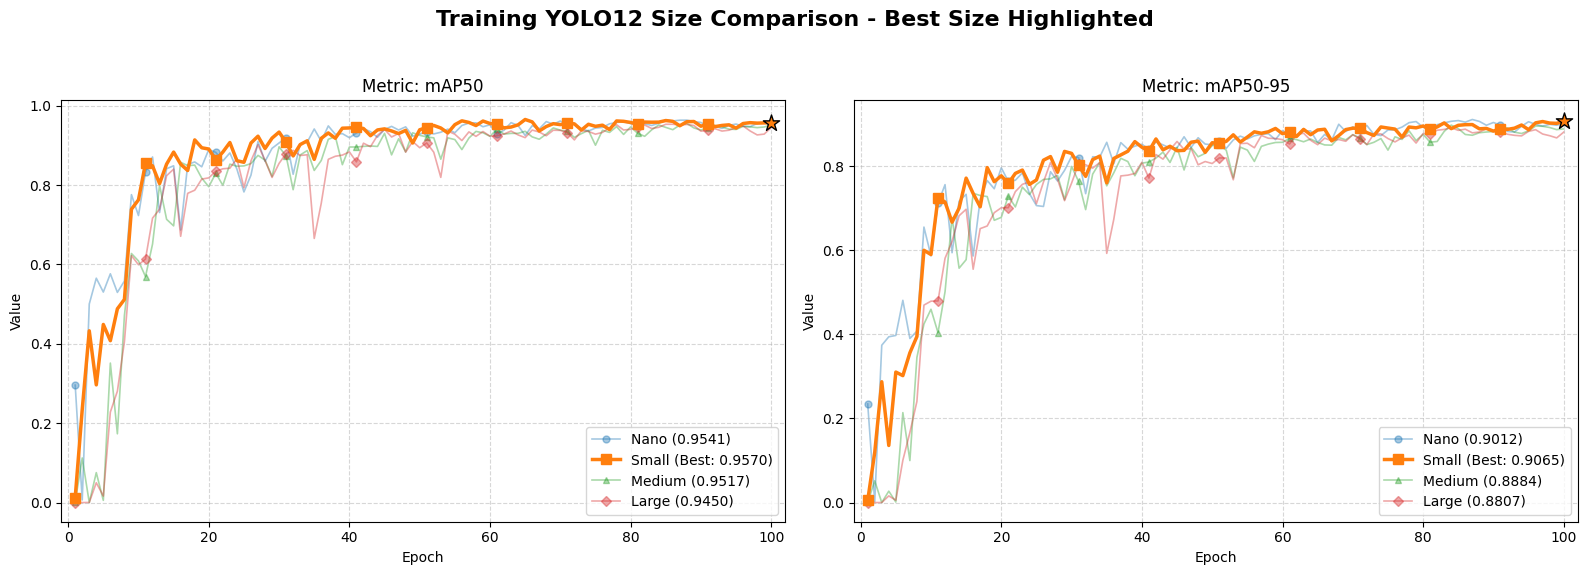

In [3]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. KONFIGURASI ---
base = Path("results")
version = "yolo_v12/object_detection_all_class_no_augmentation"
sizes = ["nano", "small", "medium", "large"]

# Map Metrik
metric_map = {
    "mAP50": "metrics/mAP50(B)",
    "mAP50-95": "metrics/mAP50-95(B)",
}

# Style Config: Warna & Marker untuk setiap ukuran
styles = {
    "nano":   {"color": "#1f77b4", "marker": "o", "label": "Nano"},   # Blue / Circle
    "small":  {"color": "#ff7f0e", "marker": "s", "label": "Small"},  # Orange / Square
    "medium": {"color": "#2ca02c", "marker": "^", "label": "Medium"}, # Green / Triangle Up
    "large":  {"color": "#d62728", "marker": "D", "label": "Large"},  # Red / Diamond
}

# Persiapkan Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Training YOLO12 Size Comparison - Best Size Highlighted", fontsize=16, fontweight='bold')

for idx, (metric_label, metric_col) in enumerate(metric_map.items()):
    ax = axes[idx]
    
    # --- 2. LOAD DATA ---
    loaded_data = [] 

    for size in sizes:
        csv_path = base / version / "training" / size / "results.csv"
        
        if not csv_path.exists():
            print(f"[SKIP] Missing: {csv_path}")
            continue
            
        try:
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns] # Clean headers
            
            if metric_col not in df.columns:
                print(f"[WARN] Metric {metric_col} not found in {size}")
                continue

            # Ambil data
            epochs = df["epoch"]
            values = df[metric_col]
            final_value = values.iloc[-1]
            
            loaded_data.append({
                "size": size,
                "epochs": epochs,
                "values": values,
                "final_value": final_value
            })
            
        except Exception as e:
            print(f"[ERR] Error processing {csv_path}: {e}")

    # Skip jika data kosong
    if not loaded_data:
        continue

    # --- 3. CARI BEST MODEL ---
    best_model_data = max(loaded_data, key=lambda x: x['final_value'])
    best_size_name = best_model_data['size']

    # --- 4. PLOTTING ---
    for data in loaded_data:
        size = data['size']
        style = styles.get(size, {"color": "gray", "marker": ".", "label": size})
        
        is_best = (size == best_size_name)
        
        # Style Logic: Highlight vs Fade
        if is_best:
            alpha = 1.0
            linewidth = 2.5
            zorder = 10
            label_text = f"{style['label']} (Best: {data['final_value']:.4f})"
        else:
            alpha = 0.4
            linewidth = 1.2
            zorder = 1
            label_text = f"{style['label']} ({data['final_value']:.4f})"

        # Plot Garis
        ax.plot(
            data['epochs'],
            data['values'],
            label=label_text,
            color=style['color'],
            linewidth=linewidth,
            alpha=alpha,
            zorder=zorder,
            marker=style['marker'],
            markevery=max(1, len(data['epochs']) // 10), # Agar marker rapi (setiap 10%)
            markersize=7 if is_best else 5
        )

        # Highlight Endpoint Pemenang
        if is_best:
            ax.scatter(
                data['epochs'].iloc[-1], 
                data['final_value'], 
                color=style['color'], 
                s=150, 
                edgecolor='black', 
                zorder=11,
                marker='*' # Bintang
            )

    # Estetika Subplot
    ax.set_title(f"Metric: {metric_label}", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Legend
    ax.legend(loc="best", fontsize=10)
    ax.margins(x=0.02)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

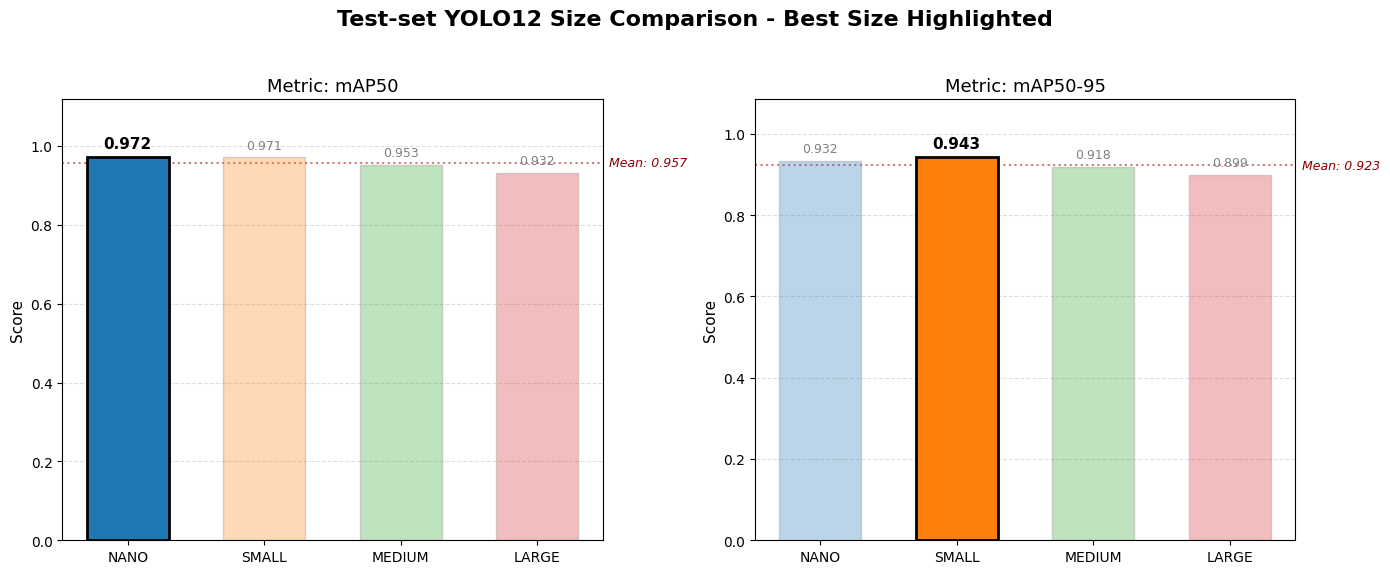

In [4]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. KONFIGURASI ---
base = Path("results")
version = "yolo_v12/object_detection_all_class_no_augmentation"
variants = ["nano", "small", "medium", "large"]

# Menggunakan palet warna standar project ini agar konsisten
# (Nano=Biru, Small=Oranye, Medium=Hijau, Large=Merah)
colors = {
    "nano":   "#1f77b4",
    "small":  "#ff7f0e",
    "medium": "#2ca02c",
    "large":  "#d62728",
}

def load_all_row(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    row = df[df["class"] == "all"]
    if row.empty:
        raise ValueError(f"Missing Class == 'all' in {csv_path}")
    return row.iloc[0]

# --- 2. PERSIAPAN DATA ---
results_data = []
for variant in variants:
    csv_path = base / version / "validation" / variant / "class_metrics_validation.csv"
    
    row_data = {"variant": variant}
    if not csv_path.exists():
        print(f"[SKIP] Missing: {csv_path}")
        row_data["mAP50"] = np.nan
        row_data["mAP50-95"] = np.nan
    else:
        try:
            r = load_all_row(csv_path)
            row_data["mAP50"] = float(r["mAP50"])
            row_data["mAP50-95"] = float(r["mAP50-95"])
        except Exception as e:
            print(f"[ERR] Error reading {csv_path}: {e}")
            row_data["mAP50"] = np.nan
            row_data["mAP50-95"] = np.nan
            
    results_data.append(row_data)

df = pd.DataFrame(results_data)

# --- 3. VISUALISASI ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Test-set YOLO12 Size Comparison - Best Size Highlighted", fontsize=16, fontweight='bold')

metrics = ["mAP50", "mAP50-95"]
x = np.arange(len(variants))
bar_w = 0.6 

for ax, metric in zip(axes, metrics):
    # Cari nilai maksimum untuk highlight
    max_val = df[metric].max()
    
    # Loop manual agar kontrol style lebih mudah per bar
    for i, row in df.iterrows():
        variant = row['variant']
        val = row[metric]
        
        if pd.isna(val): continue

        # Logic: Winner takes all highlighting
        is_best = np.isclose(val, max_val)
        
        # Style Definition
        if is_best:
            alpha = 1.0
            linewidth = 2.0
            edgecolor = 'black'
            zorder = 5
        else:
            alpha = 0.3 # Pudar
            linewidth = 1.0
            edgecolor = 'gray'
            zorder = 3

        # Plot Bar
        bar = ax.bar(
            variant.upper(), 
            val, 
            color=colors.get(variant, "gray"),
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            width=bar_w,
            zorder=zorder
        )
        
        # Annotasi Text (Nilai di atas bar)
        ax.text(
            bar[0].get_x() + bar[0].get_width()/2., 
            val + 0.015, # Jarak text dari bar
            f'{val:.3f}',
            ha='center', 
            va='bottom', 
            fontsize=11 if is_best else 9,
            fontweight='bold' if is_best else 'normal',
            color='black' if is_best else 'gray'
        )

    # Estetika Grafik
    ax.set_title(f"Metric: {metric}", fontsize=13)
    ax.set_ylabel("Score", fontsize=11)
    
    # Atur batas Y agar text tidak terpotong
    ax.set_ylim(0, max_val * 1.15)
    
    # Grid di belakang bar
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

    # Garis Rata-rata (Opsional, pemanis analisis)
    mean_val = df[metric].mean()
    ax.axhline(mean_val, color='darkred', linestyle=':', alpha=0.5, zorder=1)
    # Menambahkan text rata-rata di samping kanan grafik
    ax.text(len(variants)-0.5, mean_val, f' Mean: {mean_val:.3f}', 
            va='center', fontsize=9, color='darkred', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 10K Images

### Visualisasi model dilatih 10K image

### Visualisasi model dilatih 750 image

### Visualisasi model dilatih few-shot image

# Graph comparison with augmentation

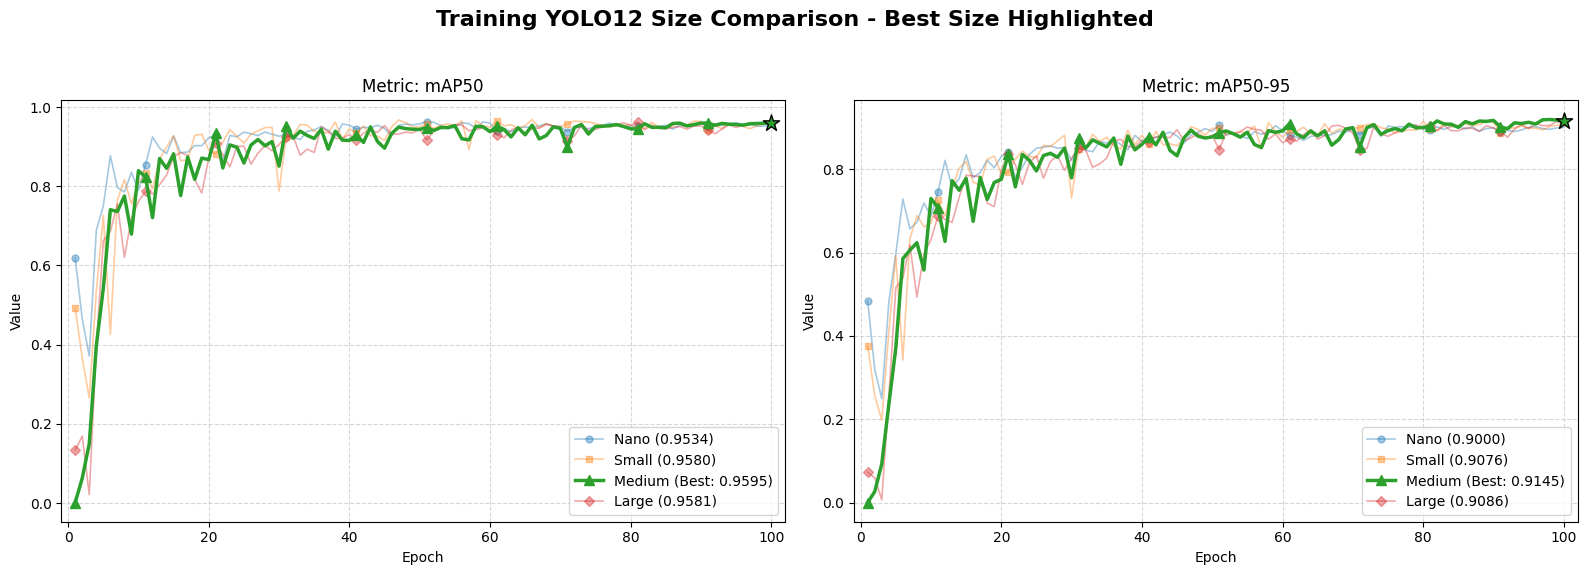

In [2]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. KONFIGURASI ---
base = Path("results")
version = "yolo_v12/object_detection_all_class_with_augmentation"
sizes = ["nano", "small", "medium", "large"]

# Map Metrik
metric_map = {
    "mAP50": "metrics/mAP50(B)",
    "mAP50-95": "metrics/mAP50-95(B)",
}

# Style Config: Warna & Marker untuk setiap ukuran
styles = {
    "nano":   {"color": "#1f77b4", "marker": "o", "label": "Nano"},   # Blue / Circle
    "small":  {"color": "#ff7f0e", "marker": "s", "label": "Small"},  # Orange / Square
    "medium": {"color": "#2ca02c", "marker": "^", "label": "Medium"}, # Green / Triangle Up
    "large":  {"color": "#d62728", "marker": "D", "label": "Large"},  # Red / Diamond
}

# Persiapkan Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Training YOLO12 Size Comparison - Best Size Highlighted", fontsize=16, fontweight='bold')

for idx, (metric_label, metric_col) in enumerate(metric_map.items()):
    ax = axes[idx]
    
    # --- 2. LOAD DATA ---
    loaded_data = [] 

    for size in sizes:
        csv_path = base / version / "training" / size / "results.csv"
        
        if not csv_path.exists():
            print(f"[SKIP] Missing: {csv_path}")
            continue
            
        try:
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns] # Clean headers
            
            if metric_col not in df.columns:
                print(f"[WARN] Metric {metric_col} not found in {size}")
                continue

            # Ambil data
            epochs = df["epoch"]
            values = df[metric_col]
            final_value = values.iloc[-1]
            
            loaded_data.append({
                "size": size,
                "epochs": epochs,
                "values": values,
                "final_value": final_value
            })
            
        except Exception as e:
            print(f"[ERR] Error processing {csv_path}: {e}")

    # Skip jika data kosong
    if not loaded_data:
        continue

    # --- 3. CARI BEST MODEL ---
    best_model_data = max(loaded_data, key=lambda x: x['final_value'])
    best_size_name = best_model_data['size']

    # --- 4. PLOTTING ---
    for data in loaded_data:
        size = data['size']
        style = styles.get(size, {"color": "gray", "marker": ".", "label": size})
        
        is_best = (size == best_size_name)
        
        # Style Logic: Highlight vs Fade
        if is_best:
            alpha = 1.0
            linewidth = 2.5
            zorder = 10
            label_text = f"{style['label']} (Best: {data['final_value']:.4f})"
        else:
            alpha = 0.4
            linewidth = 1.2
            zorder = 1
            label_text = f"{style['label']} ({data['final_value']:.4f})"

        # Plot Garis
        ax.plot(
            data['epochs'],
            data['values'],
            label=label_text,
            color=style['color'],
            linewidth=linewidth,
            alpha=alpha,
            zorder=zorder,
            marker=style['marker'],
            markevery=max(1, len(data['epochs']) // 10), # Agar marker rapi (setiap 10%)
            markersize=7 if is_best else 5
        )

        # Highlight Endpoint Pemenang
        if is_best:
            ax.scatter(
                data['epochs'].iloc[-1], 
                data['final_value'], 
                color=style['color'], 
                s=150, 
                edgecolor='black', 
                zorder=11,
                marker='*' # Bintang
            )

    # Estetika Subplot
    ax.set_title(f"Metric: {metric_label}", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Legend
    ax.legend(loc="best", fontsize=10)
    ax.margins(x=0.02)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

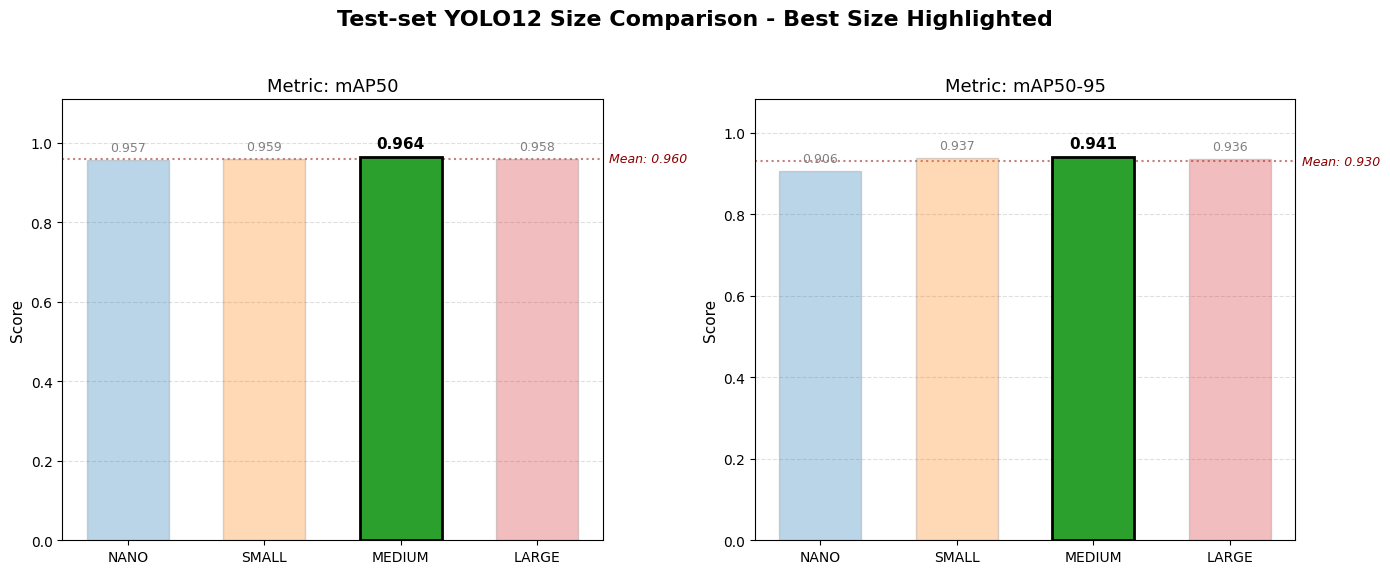

In [3]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. KONFIGURASI ---
base = Path("results")
version = "yolo_v12/object_detection_all_class_with_augmentation"
variants = ["nano", "small", "medium", "large"]

# Menggunakan palet warna standar project ini agar konsisten
# (Nano=Biru, Small=Oranye, Medium=Hijau, Large=Merah)
colors = {
    "nano":   "#1f77b4",
    "small":  "#ff7f0e",
    "medium": "#2ca02c",
    "large":  "#d62728",
}

def load_all_row(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    row = df[df["class"] == "all"]
    if row.empty:
        raise ValueError(f"Missing Class == 'all' in {csv_path}")
    return row.iloc[0]

# --- 2. PERSIAPAN DATA ---
results_data = []
for variant in variants:
    csv_path = base / version / "validation" / variant / "class_metrics_validation.csv"
    
    row_data = {"variant": variant}
    if not csv_path.exists():
        print(f"[SKIP] Missing: {csv_path}")
        row_data["mAP50"] = np.nan
        row_data["mAP50-95"] = np.nan
    else:
        try:
            r = load_all_row(csv_path)
            row_data["mAP50"] = float(r["mAP50"])
            row_data["mAP50-95"] = float(r["mAP50-95"])
        except Exception as e:
            print(f"[ERR] Error reading {csv_path}: {e}")
            row_data["mAP50"] = np.nan
            row_data["mAP50-95"] = np.nan
            
    results_data.append(row_data)

df = pd.DataFrame(results_data)

# --- 3. VISUALISASI ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Test-set YOLO12 Size Comparison - Best Size Highlighted", fontsize=16, fontweight='bold')

metrics = ["mAP50", "mAP50-95"]
x = np.arange(len(variants))
bar_w = 0.6 

for ax, metric in zip(axes, metrics):
    # Cari nilai maksimum untuk highlight
    max_val = df[metric].max()
    
    # Loop manual agar kontrol style lebih mudah per bar
    for i, row in df.iterrows():
        variant = row['variant']
        val = row[metric]
        
        if pd.isna(val): continue

        # Logic: Winner takes all highlighting
        is_best = np.isclose(val, max_val)
        
        # Style Definition
        if is_best:
            alpha = 1.0
            linewidth = 2.0
            edgecolor = 'black'
            zorder = 5
        else:
            alpha = 0.3 # Pudar
            linewidth = 1.0
            edgecolor = 'gray'
            zorder = 3

        # Plot Bar
        bar = ax.bar(
            variant.upper(), 
            val, 
            color=colors.get(variant, "gray"),
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            width=bar_w,
            zorder=zorder
        )
        
        # Annotasi Text (Nilai di atas bar)
        ax.text(
            bar[0].get_x() + bar[0].get_width()/2., 
            val + 0.015, # Jarak text dari bar
            f'{val:.3f}',
            ha='center', 
            va='bottom', 
            fontsize=11 if is_best else 9,
            fontweight='bold' if is_best else 'normal',
            color='black' if is_best else 'gray'
        )

    # Estetika Grafik
    ax.set_title(f"Metric: {metric}", fontsize=13)
    ax.set_ylabel("Score", fontsize=11)
    
    # Atur batas Y agar text tidak terpotong
    ax.set_ylim(0, max_val * 1.15)
    
    # Grid di belakang bar
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

    # Garis Rata-rata (Opsional, pemanis analisis)
    mean_val = df[metric].mean()
    ax.axhline(mean_val, color='darkred', linestyle=':', alpha=0.5, zorder=1)
    # Menambahkan text rata-rata di samping kanan grafik
    ax.text(len(variants)-0.5, mean_val, f' Mean: {mean_val:.3f}', 
            va='center', fontsize=9, color='darkred', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()